In [21]:
import os
import pandas as pd
from dotenv import load_dotenv

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.metrics import mean_squared_error, mean_absolute_error
from sklearn.model_selection import train_test_split
from xgboost import XGBRegressor

In [22]:
load_dotenv(override=True)

file_path = os.getenv('LOAD_CLEAN_PATH')

if not file_path:
    file_path = '/content/cleaned.csv'

In [23]:
try:
    df = pd.read_csv(file_path)
except FileExistsError:
    raise Exception('CRITICAL: File path not found')

In [24]:
df.columns

Index(['Compound', 'TyreLife', 'AirTemp', 'TrackTemp', 'Rainfall',
       'time_delta'],
      dtype='object')

In [25]:
df.head()

,Compound,TyreLife,AirTemp,TrackTemp,Rainfall,time_delta
0,INTERMEDIATE,2.0,16.7,26.2,True,11.414
1,INTERMEDIATE,3.0,16.4,24.8,True,9.624
2,INTERMEDIATE,4.0,16.2,24.6,False,8.666
3,INTERMEDIATE,5.0,16.3,24.3,False,8.279
4,INTERMEDIATE,6.0,16.5,24.1,False,9.395


### Mapping columns `Compund` and `Rainfall` for Regression model

In [26]:
df['Compound'] = df['Compound'].map({'INTERMEDIATE': 0, 'SOFT': 1, 'MEDIUM': 2, 'HARD': 3, 'WET': 4})
df['Rainfall'] = df['Rainfall'].map({True: 1, False: 0})

Text(0.5, 1.0, 'F1 Feature Correlation Matrix')

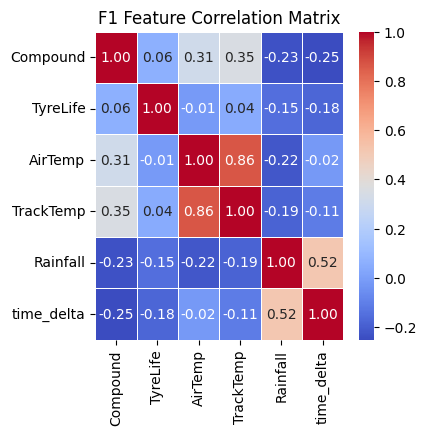

In [27]:
fig, ax = plt.subplots(figsize=(4,4))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm', fmt='.2f', linewidths=0.5)
ax.set_title('F1 Feature Correlation Matrix')

Text(0.5, 1.0, 'Tire Drop-off by Age and Compound')

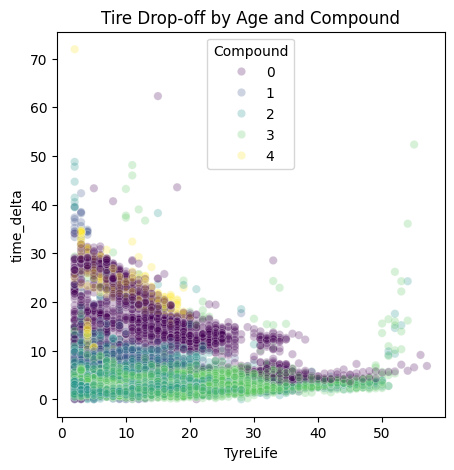

In [28]:
fig, ax = plt.subplots(figsize=(5,5))
sns.scatterplot(data=df, x='TyreLife', y='time_delta', hue='Compound', palette='viridis', alpha=0.25)
ax.set_title('Tire Drop-off by Age and Compound')

Text(0.5, 1.0, 'Rainfall vs Pace')

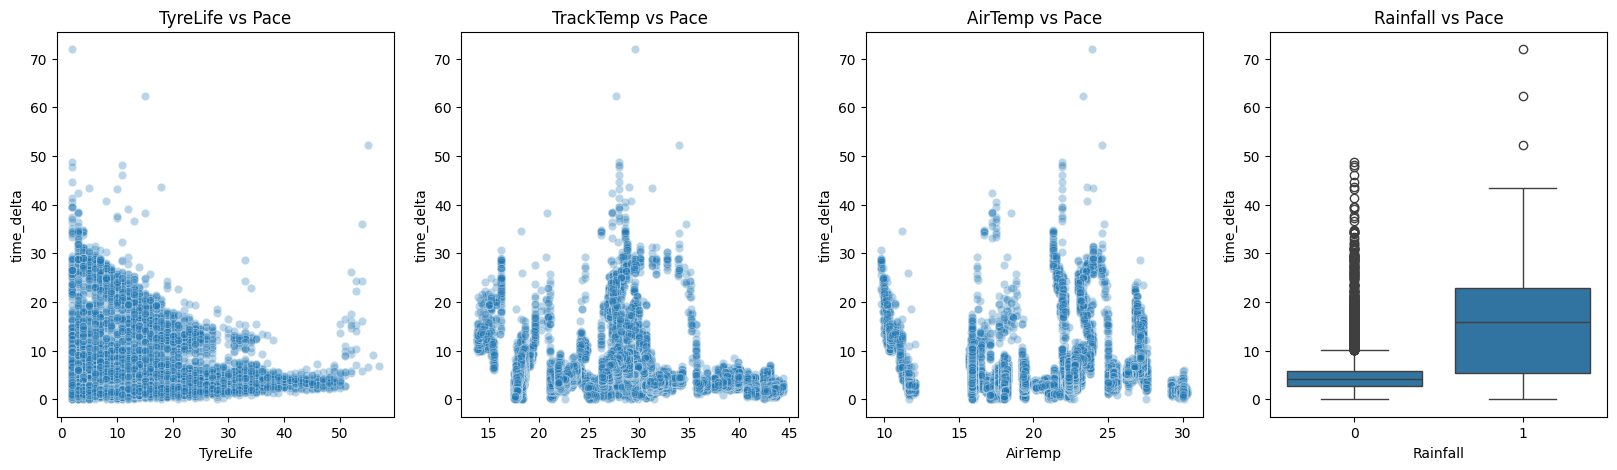

In [29]:
fig, axes = plt.subplots(1, 4, figsize=(20, 5))
sns.scatterplot(data=df, x='TyreLife', y='time_delta', ax=axes[0], alpha=0.3)
axes[0].set_title('TyreLife vs Pace')

sns.scatterplot(data=df, x='TrackTemp', y='time_delta', ax=axes[1], alpha=0.3)
axes[1].set_title('TrackTemp vs Pace')

sns.scatterplot(data=df, x='AirTemp', y='time_delta', ax=axes[2], alpha=0.3)
axes[2].set_title('AirTemp vs Pace')

sns.boxplot(data=df, x='Rainfall', y='time_delta', ax=axes[3])
axes[3].set_title('Rainfall vs Pace')

### Fixing *Compound Compound Encoding quirk*
Due to mapping categorical 'Compound' data to integers, the correlation getting disturbed

In [30]:
df = pd.get_dummies(df, columns=['Compound'])

In [31]:
X = df.drop(columns=['time_delta'])
y = df['time_delta']

In [32]:
split_index = int(len(df) * 0.8)

X_train, X_test = X.iloc[:split_index], X.iloc[split_index:]
y_train, y_test = y.iloc[:split_index], y.iloc[split_index:]

print(f'Training on {len(X_train)} historical laps.')
print(f'Testing on {len(X_test)} historical laps.')

Training on 10936 historical laps.
Testing on 2734 historical laps.


In [33]:
model = XGBRegressor(n_estimators=100, learning_rate=0.1, max_depth=5, random_state=42)

In [34]:
model.fit(X_train, y_train)

XGBRegressor(base_score=None, booster=None, callbacks=None,
             colsample_bylevel=None, colsample_bynode=None,
             colsample_bytree=None, device=None, early_stopping_rounds=None,
             enable_categorical=True, eval_metric=None, feature_types=None,
             feature_weights=None, gamma=None, grow_policy=None,
             importance_type=None, interaction_constraints=None,
             learning_rate=0.1, max_bin=None, max_cat_threshold=None,
             max_cat_to_onehot=None, max_delta_step=None, max_depth=5,
             max_leaves=None, min_child_weight=None, missing=nan,
             monotone_constraints=None, multi_strategy=None, n_estimators=100,
             n_jobs=None, num_parallel_tree=None, ...)

In [35]:
y_pred = model.predict(X_test)

In [37]:
rmse = mean_squared_error(y_test, y_pred) ** 0.5
mae = mean_absolute_error(y_test, y_pred)

In [38]:
print(f'Root Mean Squared Error (RMSE) = {rmse:.6f}')
print(f'Mean Absolute Error (MAE)      = {mae:.6f}')

Root Mean Squared Error (RMSE) = 4.322621
Mean Absolute Error (MAE)      = 3.394163
